<a href="https://colab.research.google.com/github/RachapalliMounvithaLakshmi/alfdo/blob/main/house_alfido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib


2. Load Dataset

In [ ]:
df = pd.read_csv("/content/data.csv")   # change to your dataset name
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


3. EDA & Missing Values

In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("None", inplace=True)


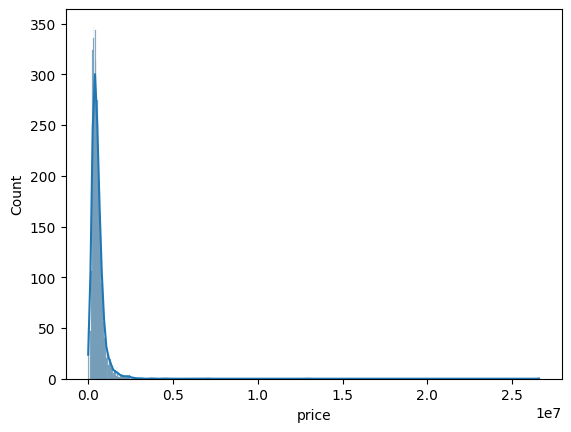

In [ ]:
sns.histplot(df["price"], kde=True)
plt.show()

4. Feature Engineering

In [ ]:
df["price"] = np.log1p(df["price"])


In [ ]:
df = pd.get_dummies(df, drop_first=True)


5. Train-Test Split

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


6. Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


7. Train Models
Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

Gradient Boosting

In [ ]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)


GradientBoostingRegressor()

8. Model Evaluation

In [ ]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()


Linear Regression
RMSE: 1.370518641877244
MAE: 0.4166821306212235

Random Forest
RMSE: 1.3999420609059403
MAE: 0.3325753466491166

Gradient Boosting
RMSE: 1.3975022191919977
MAE: 0.4772578012508072



9. Residual Analysis

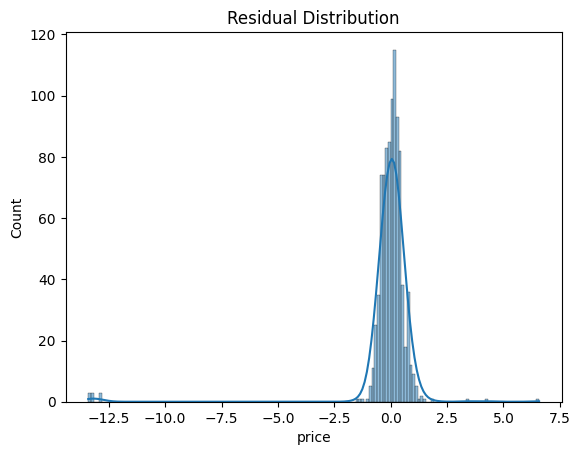

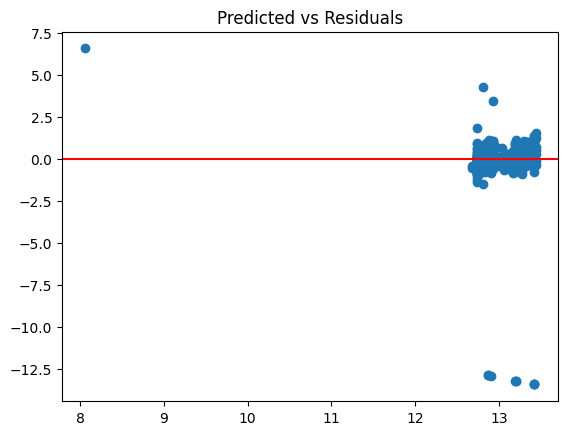

In [ ]:
best_model = gb   # usually Gradient Boosting works best

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.title("Predicted vs Residuals")
plt.show()


10. Save Model

In [ ]:
joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

11. Inference (Prediction Cell)

In [ ]:
import joblib
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")


sample_df = pd.DataFrame(0, index=[0], columns=X.columns)


sample_df['bedrooms'] = 3
sample_df['bathrooms'] = 2
sample_df['sqft_living'] = 1800
sample_df['sqft_lot'] = 5000
sample_df['yr_built'] = 2005

sample_scaled = scaler.transform(sample_df)

pred = model.predict(sample_scaled)
price = np.expm1(pred)

print("Predicted House Price:", price[0])

Predicted House Price: 403507.9754633149
